In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

In [18]:
df = pd.read_excel("final_results.xlsx")

In [19]:
# List of columns that contain (IQR ...) strings
columns_to_clean = [
    'prompt_prefill_speed', 'generation_decoder_speed', 'prefill_latency', 
    'generation_latency', 'inference_latency', 'time_to_first_token', 
    'total_energy_consumption', 'energy_per_token'
]

# Iterate through columns to remove IQR and convert to float
for col in columns_to_clean:
    # Split the string by space and keep the first part (the numeric value)
    df[col] = df[col].astype(str).str.split(' ').str[0].astype(float)

In [20]:
# Clean up model names for better visualization

df_name_clean = df.copy()

df_name_clean['model_name'] = (
    df_name_clean['model_name']
    .astype(str)
    .str.replace('Q4_K_M', '', regex=False)
    .str.replace('IQ4_XS', '', regex=False)
    .str.replace('__', '_', regex=False)
    .str.replace('--', '-', regex=False)
    .str.strip('_- ')
)


In [21]:
df8 = df_name_clean.head(8)   # Q4_K_M
df16 = df_name_clean.tail(8)  # IQ4_XS

prefill_color = "#94A6F1"
generation_color = "#FFAA4F"

w = 0.2
x = np.arange(len(df8))  # assume same model order

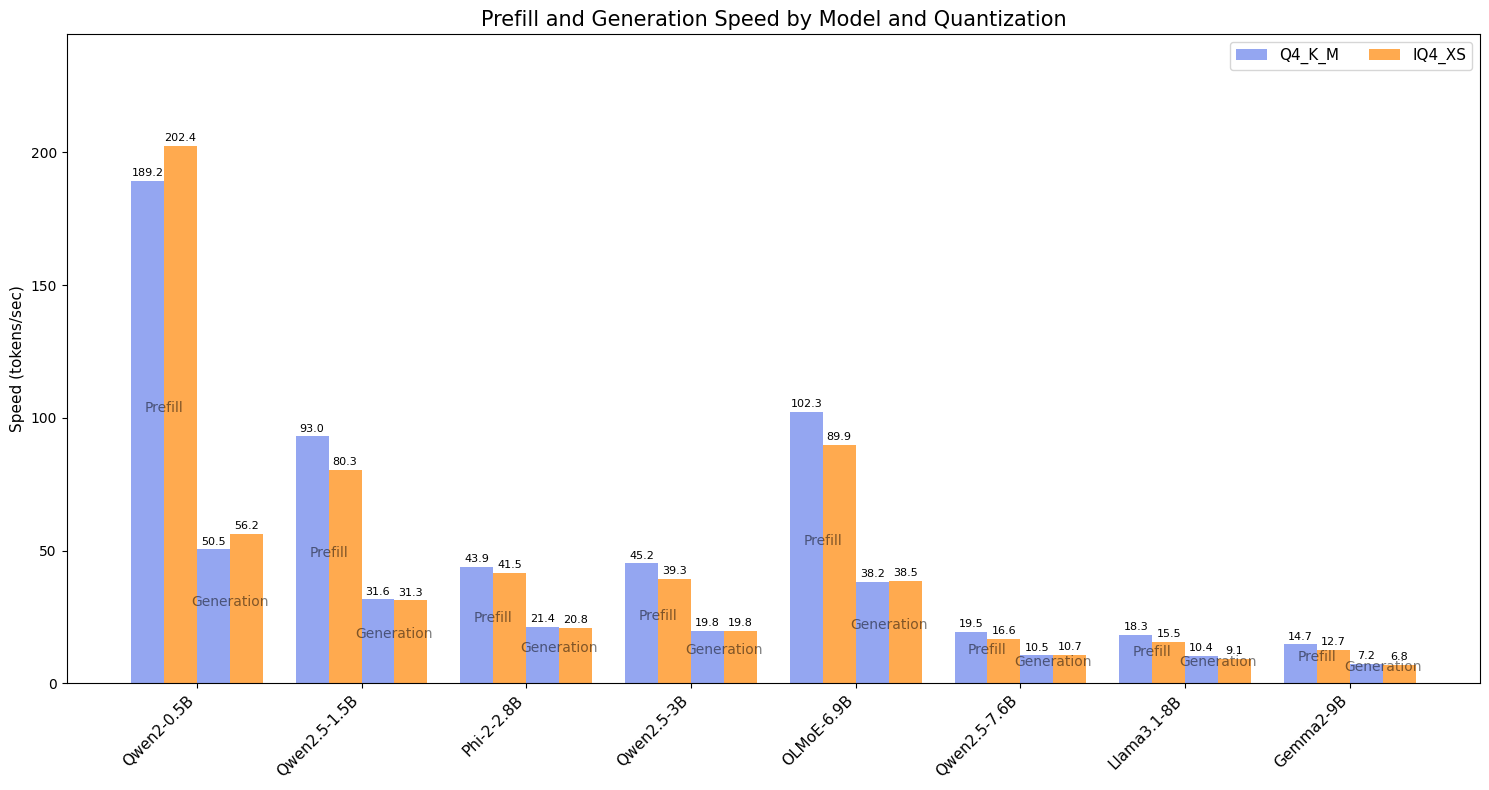

In [22]:

def label_bars(ax, bars):
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)

def label_group(ax, x_center, y_value, text):
    ax.text(
        x_center,
        y_value / 2,
        text,
        ha="center",
        va="bottom",
        fontsize=10,
        alpha=0.5
    )

# ---------------- Data ----------------
n = len(df8)
x = np.arange(n)
w = 0.2

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(15, 8))

# ---- Bars ----
b1 = ax.bar(
    x - 1.5*w,
    df8["prompt_prefill_speed"],
    w,
    label="Q4_K_M",
    color=prefill_color
)

b2 = ax.bar(
    x - 0.5*w,
    df16["prompt_prefill_speed"],
    w,
    label="IQ4_XS",
    color=generation_color
)

b3 = ax.bar(
    x + 0.5*w,
    df8["generation_decoder_speed"],
    w,
    color=prefill_color
)

b4 = ax.bar(
    x + 1.5*w,
    df16["generation_decoder_speed"],
    w,
    color=generation_color
)

# ---------------- Formatting ----------------
ax.set_xticks(x)
ax.set_xticklabels(df8["model_name"], rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Speed (tokens/sec)", fontsize=11)
ax.set_title("Prefill and Generation Speed by Model and Quantization", fontsize=15)

ax.legend(fontsize=11, ncol=2)

# ---------------- Bar Value Labels ----------------
for bars in [b1, b2, b3, b4]:
    label_bars(ax, bars)

# ---------------- Group Labels ----------------
for i in range(n):
    # Prefill group
    prefill_x = x[i] - w
    prefill_y = max(
        df8["prompt_prefill_speed"].iloc[i],
        df16["prompt_prefill_speed"].iloc[i]
    )
    label_group(ax, prefill_x, prefill_y, "Prefill")

    # Generation group
    generation_x = x[i] + w
    generation_y = max(
        df8["generation_decoder_speed"].iloc[i],
        df16["generation_decoder_speed"].iloc[i]
    )
    label_group(ax, generation_x, generation_y, "Generation")

# ---------------- Final Touch ----------------
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.show()


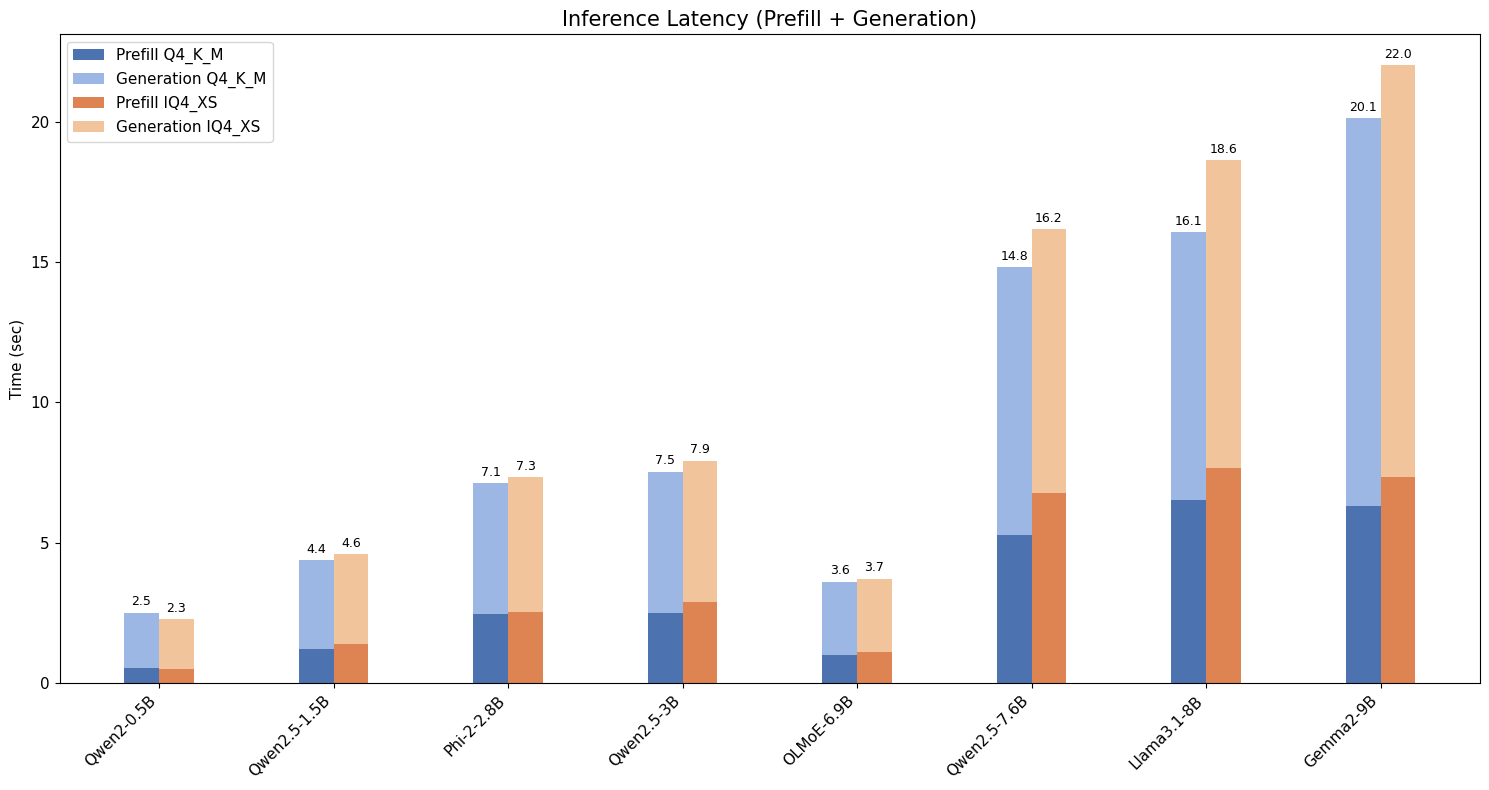

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def label_bars(ax, bars):
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

prefill_q4 = "#4C72B0"     # muted blue
gen_q4     = "#9DB7E5"     # lighter blue
prefill_iq = "#DD8452"     # warm orange
gen_iq     = "#F2C49B"     # light orange

# ---- Setup ----
x = np.arange(len(df8["model_name"]))
w = 0.2

fig, ax = plt.subplots(figsize=(15, 8))

# =======================
# Q4_K_M (df8)
# =======================
b1 = ax.bar(
    x - w/2,
    df8["prefill_latency"],
    w,
    label="Prefill Q4_K_M",
    color=prefill_q4
)

b2 = ax.bar(
    x - w/2,
    df8["generation_latency"],
    w,
    label="Generation Q4_K_M",
    bottom=df8["prefill_latency"],
    color=gen_q4,
)

# =======================
# IQ4_XS (df16)
# =======================
b3 = ax.bar(
    x + w/2,
    df16["prefill_latency"],
    w,
    label="Prefill IQ4_XS",
    color=prefill_iq,
)

b4 = ax.bar(
    x + w/2,
    df16["generation_latency"],
    w,
    label="Generation IQ4_XS",
    bottom=df16["prefill_latency"],
    color=gen_iq,
)

# ---- Formatting ----
ax.set_xticks(x)
ax.set_xticklabels(df8["model_name"], rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Time (sec)", fontsize=11)
ax.set_title("Inference Latency (Prefill + Generation)", fontsize=15)
ax.tick_params(axis="y", labelsize=11)
ax.legend(fontsize=11)

# ---- Optional: label only the top (total inference latency) ----
label_bars(ax, b2)
label_bars(ax, b4)


plt.tight_layout()
plt.show()


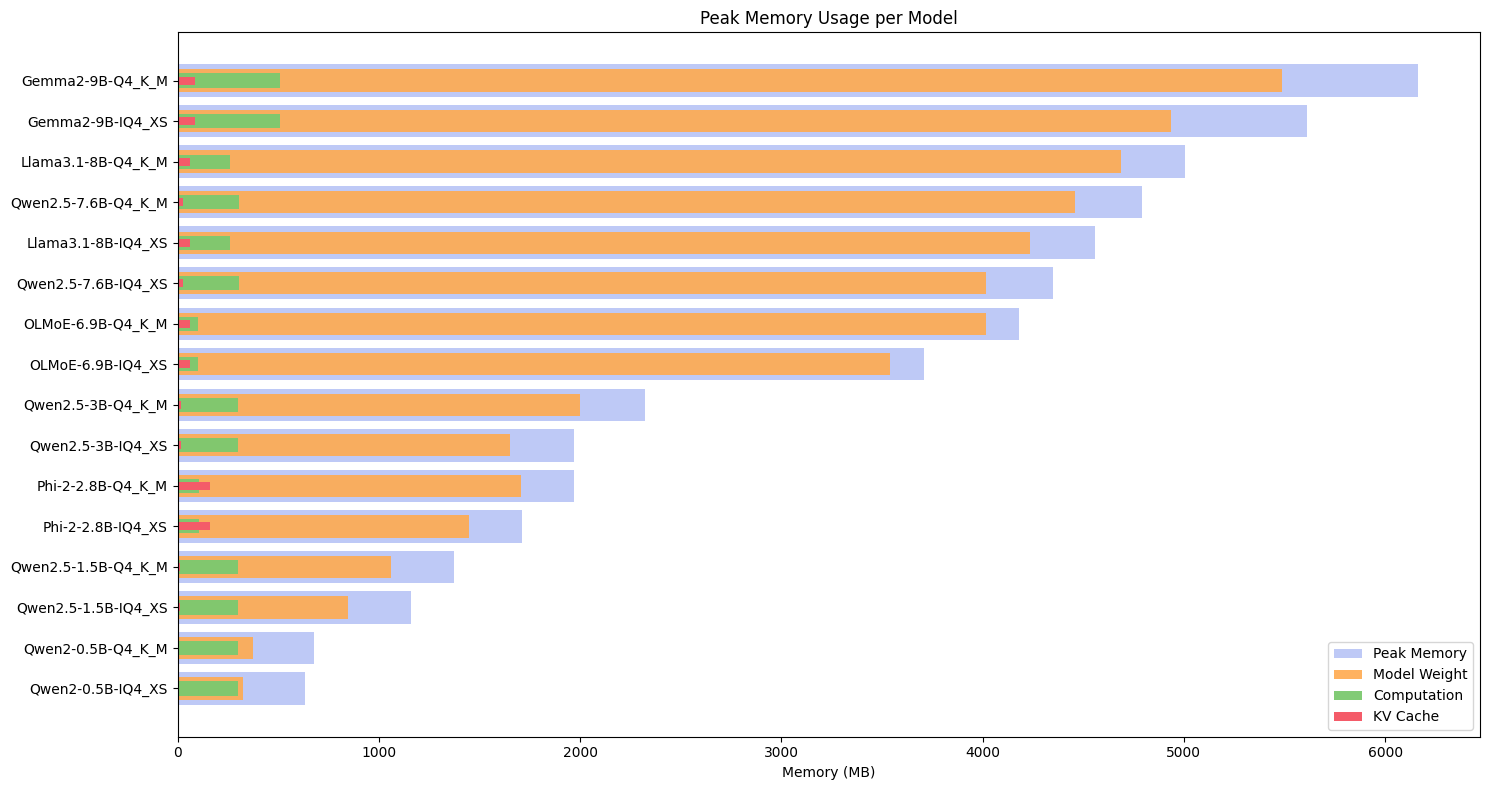

In [24]:
df_sorted_mem = df.sort_values('peak_memory', ascending=True)

plt.figure(figsize=(15, 8))

models = df_sorted_mem['model_name']
y_pos = np.arange(len(models))

# Heights (outer → inner)
h_peak = 0.8
h_weight = 0.55
h_compute = 0.35
h_kv = 0.2

# Peak Memory (outermost)
plt.barh(
    y_pos,
    df_sorted_mem['peak_memory'],
    height=h_peak,
    color="#94A6F1",
    alpha=0.6,
    label="Peak Memory"
)

# Model Weight
plt.barh(
    y_pos,
    df_sorted_mem['model_weight'],
    height=h_weight,
    color="#FFAA4F",
    alpha=0.9,
    label="Model Weight"
)

# Compute RAM
plt.barh(
    y_pos,
    df_sorted_mem['compute_RAM'],
    height=h_compute,
    color="#7BC96F",
    alpha=0.95,
    label="Computation"
)

# KV Cache
plt.barh(
    y_pos,
    df_sorted_mem['KV_cache'],
    height=h_kv,
    color="#F45B69",
    alpha=1.0,
    label="KV Cache"
)

plt.yticks(y_pos, models)
plt.xlabel("Memory (MB)")
plt.title("Peak Memory Usage per Model")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
# For keeping same color of model names

df_model_name = df[['model_name']].copy()

df_model_name['model_name'] = (
    df_model_name['model_name']
    .astype(str)
    .str.replace('Q4_K_M', '', regex=False)
    .str.replace('IQ4_XS', '', regex=False)
    .str.replace('__', '_', regex=False)
    .str.replace('--', '-', regex=False)
    .str.strip('_- ')
)


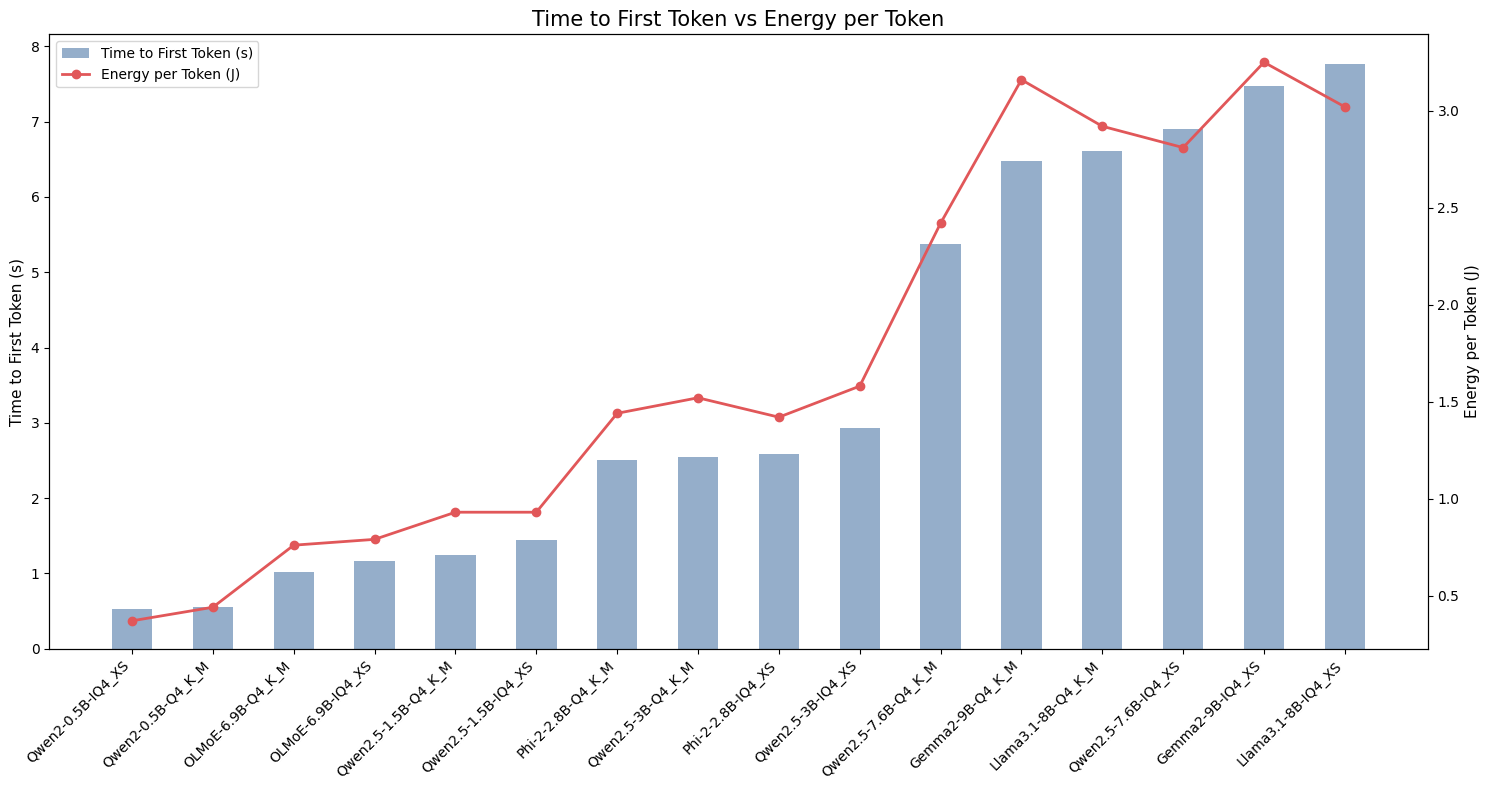

In [26]:
# Sort by Time to First Token to create a logical flow
df_sorted = df.sort_values('time_to_first_token', ascending=True)

# Create the figure and primary axis
fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot Time to First Token as Bars (Primary Axis)
bars = ax1.bar(df_sorted['model_name'], df_sorted['time_to_first_token'], color='#4e79a7', alpha=0.6, width=0.5, label='Time to First Token (s)')
ax1.set_ylabel('Time to First Token (s)', fontsize=11)
ax1.tick_params(axis='y')
plt.xticks(rotation=45, ha='right')

# Create secondary axis for Energy per Token
ax2 = ax1.twinx()
line = ax2.plot(df_sorted['model_name'], df_sorted['energy_per_token'], color='#e15759', marker='o', linewidth=2, label='Energy per Token (J)')
ax2.set_ylabel('Energy per Token (J)', fontsize=11)
ax2.tick_params(axis='y')

# Add title
plt.title('Time to First Token vs Energy per Token', fontsize=15)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')


plt.grid(False)
plt.tight_layout()
plt.show()

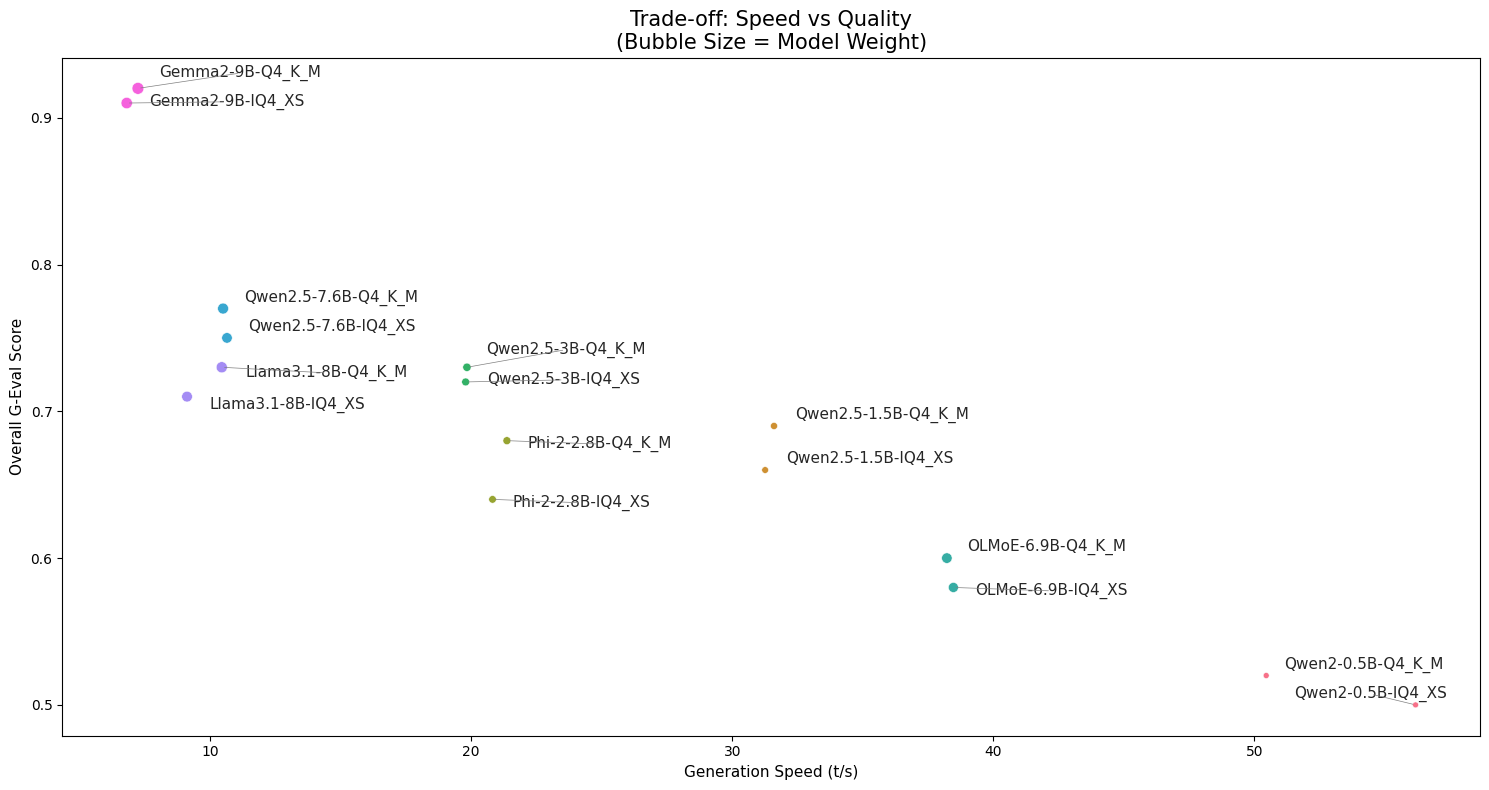

In [27]:

# Set the visual style
#sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(15, 8))
ax = sns.scatterplot(
    data=df,
    x='generation_decoder_speed',
    y='Overall_G-Eval',
    hue=df_model_name['model_name'],
    size='model_weight',
    palette='husl',
    s=80,
    legend=False
)

# Titles and labels
plt.title('Trade-off: Speed vs Quality\n(Bubble Size = Model Weight)', fontsize=15)
plt.xlabel('Generation Speed (t/s)', fontsize=11)
plt.ylabel('Overall G-Eval Score', fontsize=11)

# Create text objects
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row['generation_decoder_speed'],
            row['Overall_G-Eval'],
            row['model_name'],
            fontsize=11,
            alpha=0.85
        )
    )

# Automatically adjust label positions
adjust_text(
    texts,
    ax=ax,
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle="-", lw=0.5, color="gray")
)

plt.grid(False)
plt.tight_layout()
plt.show()

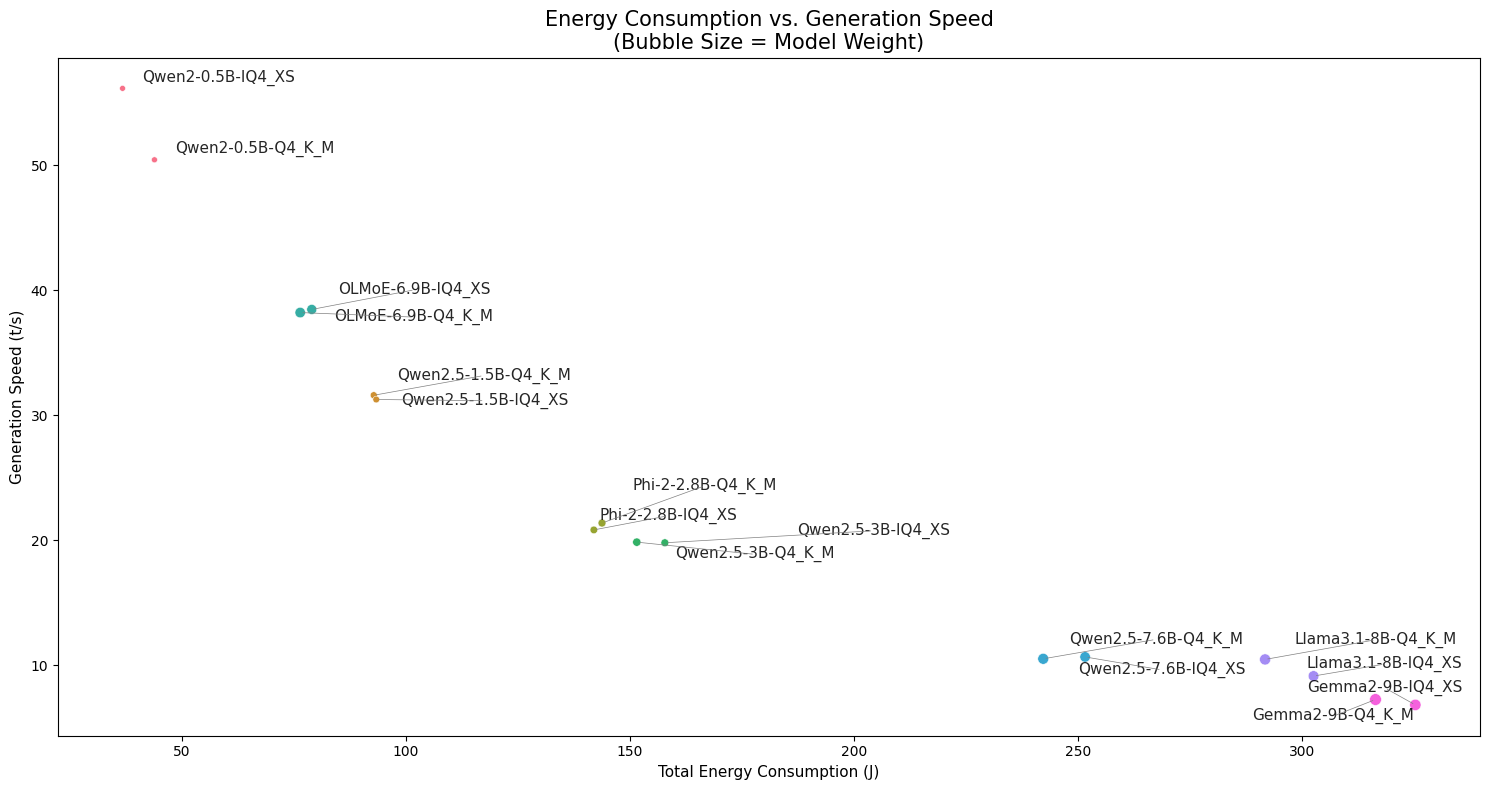

In [28]:

# Set the visual style
#sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(15, 8))
ax = sns.scatterplot(
    data=df,
    x='total_energy_consumption',
    y='generation_decoder_speed',
    hue=df_model_name['model_name'],
    size='model_weight',
    palette='husl',
    s=80,
    legend=False
)

# Titles and labels
plt.title('Energy Consumption vs. Generation Speed\n(Bubble Size = Model Weight)', fontsize=15)
plt.xlabel('Total Energy Consumption (J)', fontsize=11)
plt.ylabel('Generation Speed (t/s)', fontsize=11)

# Create text objects
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row['total_energy_consumption'],
            row['generation_decoder_speed'],
            row['model_name'],
            fontsize=11,
            alpha=0.85
        )
    )

# Automatically adjust label positions
adjust_text(
    texts,
    ax=ax,
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle="-", lw=0.5, color="gray")
)

plt.grid(False)
plt.tight_layout()
plt.show()


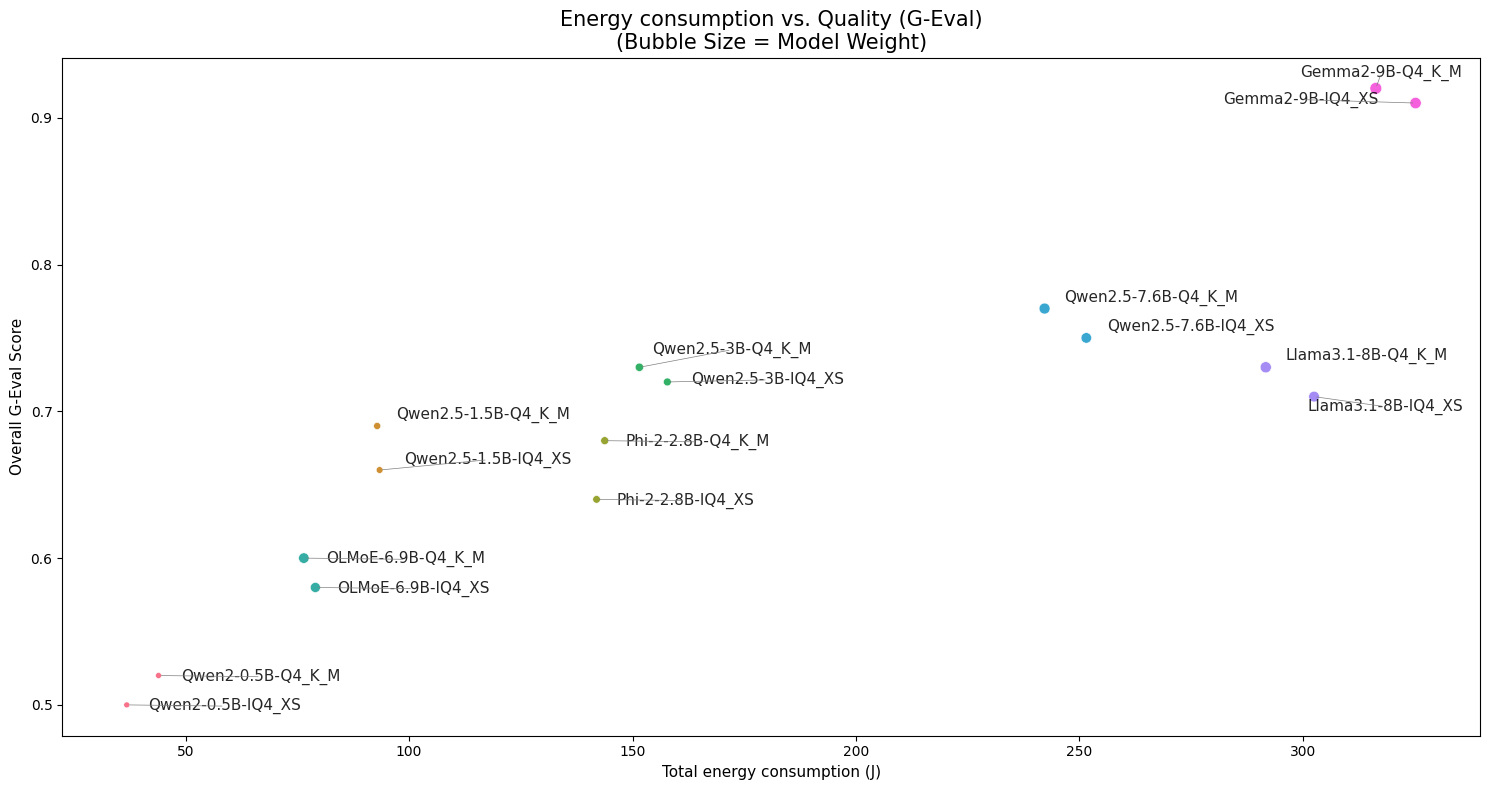

In [29]:

# Create the scatter plot
plt.figure(figsize=(15, 8))
ax = sns.scatterplot(
    data=df,
    x='total_energy_consumption',
    y='Overall_G-Eval',
    hue=df_model_name['model_name'],
    size='model_weight',
    palette='husl',
    s=80,
    legend=False
)

# Titles and labels
plt.title('Energy consumption vs. Quality (G-Eval)\n(Bubble Size = Model Weight)', fontsize=15)
plt.xlabel('Total energy consumption (J)', fontsize=11)
plt.ylabel('Overall G-Eval Score', fontsize=11)

# Create text objects
texts = []
for _, row in df.iterrows():
    texts.append(
        plt.text(
            row['total_energy_consumption'],
            row['Overall_G-Eval'],
            row['model_name'],
            fontsize=11,
            alpha=0.85
        )
    )

# Automatically adjust label positions
adjust_text(
    texts,
    ax=ax,
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle="-", lw=0.5, color="gray")
)

plt.grid(False)
plt.tight_layout()
plt.show()
